<a href="https://colab.research.google.com/github/Ehsanstp/Lensing/blob/main/NN_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/lens-finding-test.zip"
extract_path = "/content/lens_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction dune!")


Extraction complete!


In [ ]:

'''
import os

directory = '/content/lens_data'
for filename in os.listdir(directory):
    if filename.endswith(".npy"):
        file_path = os.path.join(directory, filename)
        os.remove(file_path)
        print(f"Deleted: {file_path}")
        '''

'\nimport os\n\ndirectory = \'/content/lens_data\'\nfor filename in os.listdir(directory):\n    if filename.endswith(".npy"):\n        file_path = os.path.join(directory, filename)\n        os.remove(file_path)\n        print(f"Deleted: {file_path}")\n        '

In [ ]:
import os

print("Files in train_lenses:", os.listdir("/content/lens_data/train_lenses"))
print("Files in train_nonlenses:", os.listdir("/content/lens_data/train_nonlenses"))

print("Files in test_lenses:", os.listdir("/content/lens_data/test_lenses"))
print("Files in test_nonlenses:", os.listdir("/content/lens_data/test_nonlenses"))


Files in train_lenses: ['941.npy', '1361.npy', '160.npy', '363.npy', '243.npy', '1582.npy', '439.npy', '1368.npy', '355.npy', '313.npy', '826.npy', '205.npy', '949.npy', '973.npy', '849.npy', '468.npy', '566.npy', '1149.npy', '640.npy', '993.npy', '440.npy', '1305.npy', '215.npy', '892.npy', '544.npy', '104.npy', '178.npy', '1709.npy', '1308.npy', '374.npy', '1233.npy', '656.npy', '1681.npy', '602.npy', '461.npy', '1296.npy', '403.npy', '1656.npy', '272.npy', '812.npy', '1673.npy', '181.npy', '10.npy', '1137.npy', '1730.npy', '889.npy', '296.npy', '1281.npy', '431.npy', '420.npy', '1658.npy', '1219.npy', '1501.npy', '1606.npy', '1174.npy', '131.npy', '758.npy', '827.npy', '1249.npy', '670.npy', '1578.npy', '321.npy', '846.npy', '563.npy', '477.npy', '370.npy', '335.npy', '792.npy', '1075.npy', '554.npy', '320.npy', '15.npy', '301.npy', '1520.npy', '342.npy', '588.npy', '383.npy', '736.npy', '16.npy', '1003.npy', '1162.npy', '1052.npy', '574.npy', '490.npy', '1700.npy', '1128.npy', '385

In [ ]:
import numpy as np

# Path to the file
file_path = "/content/lens_data/train_lenses/"

# Count image files only (e.g., PNG, JPG)
def load_npy_files_from_dir(directory):
    image_extensions = ('.npy')
    files = [f for f in os.listdir(directory) if f.endswith('.npy')]

    return files

# Call the function to assign the 'files' variable
files = load_npy_files_from_dir(file_path)  # Call the function here

print(f"Number of image files in '{file_path}': {len(files)}")


Number of image files in '/content/lens_data/train_lenses/': 1730


In [ ]:
import numpy as np
import os


# Define function to load .npy files from a directory
def load_npy_files_from_dir(directory):
    # Get list of all .npy files in the directory
    files = [f for f in os.listdir(directory) if f.endswith('.npy')]

    # Initialize a list to store the data
    data = []

    # Loop over each file, load it, and append to the data list
    for file in files:
        file_path = os.path.join(directory, file)
        data.append(np.load(file_path))

    return data


# APATOTO lagbe naaaaaaaaaaaaaaaaaaaaaaaaaaa

# Augmentation of the lens image
# Creating Augmented images from the simulated lens:
import os
import numpy as np
import random
from PIL import Image, ImageOps
import torchvision.transforms as T

# Paths
input_dir = "/content/lens_data/train_lenses"  # original 1730 images in .npy format
output_dir = '/content/lens_data/train_lenses'  # where 1730 x 6 images will be saved in .npy format

os.makedirs(output_dir, exist_ok=True)

# Custom function for applying random zoom
import random
from PIL import Image, ImageOps
import torchvision.transforms.functional as TF
import torch

def random_zoom(img, scale_range=(0.8, 1.2), output_size=(64, 64)):
    # Random scale factor
    scale_factor = random.uniform(*scale_range)
    width, height = img.size
    new_width = int(width * scale_factor)
    new_height = int(height * scale_factor)

    # Resize with zoom
    img = img.resize((new_width, new_height), Image.BILINEAR)

    if scale_factor >= 1:
        # Center crop
        left = (new_width - output_size[0]) // 2
        top = (new_height - output_size[1]) // 2
        right = left + output_size[0]
        bottom = top + output_size[1]
        img = img.crop((left, top, right, bottom))
    else:
        # Pad to output size
        border_color = (0, 0, 0)
        delta_w = output_size[0] - new_width
        delta_h = output_size[1] - new_height
        padding = (delta_w // 2, delta_h // 2, delta_w - delta_w // 2, delta_h - delta_h // 2)
        img = ImageOps.expand(img, padding, fill=border_color)

    # Ensure final size (safety net)
    img = img.resize(output_size, Image.BILINEAR)

    # Convert to numpy
    img_np = np.array(img)
    img_np = img_np.transpose(0, 1, 2)

    return img_np

# Augmentations (applied independently)
augmentations = [
    ("hflip", T.RandomHorizontalFlip(p=1.0)),
    ("vflip", T.RandomVerticalFlip(p=1.0)),
    ("zoom", random_zoom),
    ("blur", T.GaussianBlur(kernel_size=3)),
    ("invert", T.RandomInvert(p=1.0)),
    ("sharpness", T.RandomAdjustSharpness(sharpness_factor=2, p=1.0))
]

# Load .npy files and apply augmentations
for idx, filename in enumerate(os.listdir(input_dir)):
    if filename.lower().endswith('.npy'):
        npy_path = os.path.join(input_dir, filename)
        image = np.load(npy_path)  # Load image as a NumPy array (shape should be (3, 64, 64))

        # Convert NumPy array to PIL image for transformations
        pil_img = Image.fromarray((image.transpose(1, 2, 0) * 255).astype(np.uint8))  # Convert from (3, 64, 64) to (height, width, channels)
        pil_img = pil_img.convert("RGB")

        base_name = os.path.splitext(filename)[0]

        for suffix, aug in augmentations:
            if suffix == "zoom":  # Apply zoom manually since it's a custom function
                transformed = aug(pil_img)  # Zoom happens here
            else:
                transformed = aug(pil_img)  # Apply other augmentations (flips, sharpness, etc.)

            # Convert back to NumPy array (shape should be (3, 64, 64))
            augmented_img = np.array(transformed).transpose(2, 0, 1) / 255.0  # Normalize to [0, 1]

            # Save the augmented .npy file
            out_name = f"{base_name}_{suffix}.npy"
            out_path = os.path.join(output_dir, out_name)
            np.save(out_path, augmented_img)  # Save as .npy file

        # Optional: print progress
        if (idx + 1) % 100 == 0:
            print(f"Processed {idx+1}/{len(os.listdir(input_dir))} images")

print(":) All augmented imgs saved as .npy files!")



Processed 100/2330 images
Processed 200/2930 images
Processed 300/3530 images
Processed 400/4130 images
Processed 500/4730 images
Processed 600/5330 images
Processed 700/5930 images
Processed 800/6530 images
Processed 900/7130 images
Processed 1000/7730 images
Processed 1100/8330 images
Processed 1200/8930 images
Processed 1300/9530 images
Processed 1400/10130 images
Processed 1500/10730 images
Processed 1600/11330 images
Processed 1700/11930 images
✅ All augmented images saved as .npy files!


In [ ]:
# Printout the lens file no

# Set paths for the data folders
lens_data_path = '/content/lens_data'
file_path = "/content/lens_data/train_lenses/"

# Count image files only (e.g., PNG, JPG)
def load_npy_files_from_dir(directory):
    data = []
    for filename in os.listdir(directory):
        if filename.endswith('.npy'):
            file_path = os.path.join(directory, filename)
            img = np.load(file_path)
            data.append(img)
    return np.stack(data)

# Call the function to assign the 'files' variable
files = load_npy_files_from_dir(file_path)  # Call the function here

print(f"Number of image files in '{file_path}': {len(files)}")

# Load data from train_lenses, train_nonlenses, test_lenses, and test_nonlenses
train_lenses = load_npy_files_from_dir(os.path.join(lens_data_path, 'train_lenses'))
train_nonlenses = load_npy_files_from_dir(os.path.join(lens_data_path, 'train_nonlenses'))
test_lenses = load_npy_files_from_dir(os.path.join(lens_data_path, 'test_lenses'))
test_nonlenses = load_npy_files_from_dir(os.path.join(lens_data_path, 'test_nonlenses'))


Number of image files in '/content/lens_data/train_lenses/': 12110


In [ ]:
# @title Deletion of files
import os

folder = "/content/lens_data/train_lenses"
aug_suffixes = ["_hflip", "_vflip", "_zoom", "_blur", "_invert", "_sharpness"]

deleted = 0
for file in os.listdir(folder):
    if file.endswith(".npy") and any(suffix in file for suffix in aug_suffixes):
        os.remove(os.path.join(folder, file))
        deleted += 1

print(f"🗑️ Deleted {deleted} augmented .npy files from {folder}")


🗑️ Deleted 10380 augmented .npy files from /content/lens_data/train_lenses


In [11]:
import os
import numpy as np

root_dir = "/content/lens_data/train_lenses"
filename = "1233_zoom.npy"
file_path = os.path.join(root_dir, filename)

try:
    image = np.load(file_path)
    print("Loaded image shape:", image.shape)
except FileNotFoundError:
    print("File not found:", file_path)

len(train_lenses), len(train_nonlenses)

Loaded image shape: (3, 64, 64)


(12110, 28675)

In [12]:
# prompt: if any image is not 3x64x64 print it

# Load and check shape of .npy files
for i, file_name in enumerate(files):
    img_path = file_path
    try:
      img = np.load(img_path)  # Load the image data
      if not isinstance(img, np.ndarray) or img.shape != (3, 64, 64):
          print(f"Issue at index {i}: type={type(img)}, shape={getattr(img, 'shape', 'N/A')}, file={file_name}")
    except Exception as e:
      print(f"Error loading file {file_name}: {e}")


In [13]:
import torch
import numpy as np
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Define transformations (adjust for 3-channel images)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # For RGB images
])

# Custom Dataset Class to handle .npy files
class LensingDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data  # list of .npy file paths or actual image arrays
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Load an image array (shape should be (3, 64, 64))
        image = self.data[idx]
        label = self.labels[idx]

        # Ensure it's a NumPy array
        if isinstance(image, np.ndarray):
            image = torch.tensor(image, dtype=torch.float32)  # Convert NumPy to Tensor

        return image, torch.tensor(label, dtype=torch.long)

# Assuming train_lenses, train_nonlenses, test_lenses, test_nonlenses are lists of actual image arrays

# Create labels (1 = lens, 0 = non-lens)
train_labels = np.concatenate([np.ones(len(train_lenses)), np.zeros(len(train_nonlenses))])
test_labels = np.concatenate([np.ones(len(test_lenses)), np.zeros(len(test_nonlenses))])

# Combine lenses and non-lenses data
train_data = np.concatenate([train_lenses, train_nonlenses], axis=0)  # Maintain (num_images, 3, 64, 64)
test_data = np.concatenate([test_lenses, test_nonlenses], axis=0)  # Same here

# Print shapes to ensure everything is loaded correctly
print(f"Train Data Shape: {train_data.shape}")  # Expected: (num_images, 3, 64, 64)
print(f"Test Data Shape: {test_data.shape}")  # Expected: (num_images, 3, 64, 64)

# Create Dataset and DataLoader objects
train_dataset = LensingDataset(train_data, train_labels, transform)
test_dataset = LensingDataset(test_data, test_labels, transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Get some random training images to inspect
dataiter = iter(train_loader)
images, labels = next(dataiter)


Train Data Shape: (40785, 3, 64, 64)
Test Data Shape: (19650, 3, 64, 64)


In [14]:
# prompt: print folder structure of lens_data except replace all .npy files with single ''images'' under each subfiles

import os

def print_folder_structure(root_dir):
  for dirpath, dirnames, filenames in os.walk(root_dir):
    level = dirpath.replace(root_dir, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(dirpath)}/')
    subindent = '  ' * (level + 1)
    if any(f.endswith(".npy") for f in filenames):
      print(f'{subindent}images')
    else:
      for f in filenames:
        print(f'{subindent}{f}')

print_folder_structure('/content/lens_data')


lens_data/
  train_lenses/
    images
  train_nonlenses/
    images
  __MACOSX/
    ._test_nonlenses
    ._train_lenses
    ._train_nonlenses
    ._test_lenses
    train_lenses/
      images
    train_nonlenses/
      images
    test_lenses/
      images
    test_nonlenses/
      images
  test_lenses/
    images
  test_nonlenses/
    images


In [15]:
print(f"Number of training lenses: {len(train_lenses)}")
print(f"Number of training non-lenses: {len(train_nonlenses)}")
print(f"Number of testing lenses: {len(test_lenses)}")
print(f"Number of testing non-lenses: {len(test_nonlenses)}")

Number of training lenses: 12110
Number of training non-lenses: 28675
Number of testing lenses: 195
Number of testing non-lenses: 19455


In [ ]:
# prompt: print image shape and label
'''
The images tensor is created using next(iter(train_loader)), which returns a batch of images and labels from the train_loader. The train_loader is configured with a batch_size of 32, meaning that each batch will contain 32 images. Therefore, when you try to access images[100], you are attempting to access an index beyond the range of available images in the current batch.
'''
print("Image shape:", images[10].shape)
print("Label:", labels[0].item())

Image shape: torch.Size([3, 64, 64])
Label: 1


In [ ]:
print("Image Type:", type(image))  # Should be <class 'torch.Tensor'>
print("Image dtype:", image.dtype)  # Should be torch.float32
print("Label Type:", type(labels))  # Should be <class 'torch.Tensor'>
print("Label dtype:", labels.dtype)  # Should be torch.long

Image Type: <class 'numpy.ndarray'>
Image dtype: float64
Label Type: <class 'torch.Tensor'>
Label dtype: torch.int64


In [ ]:
# See classes
class_names = train_labels

class_names

array([1., 1., 1., ..., 0., 0., 0.])

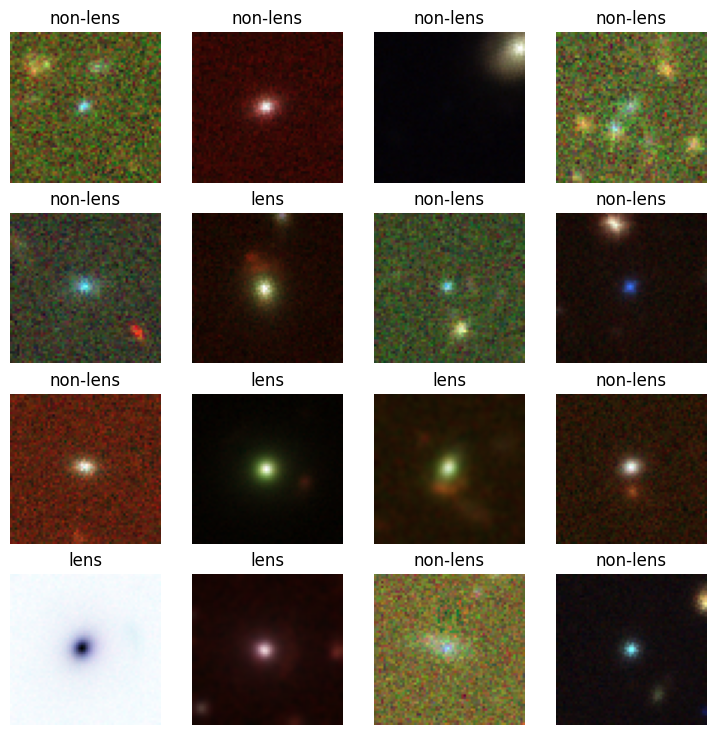

In [17]:
import matplotlib.pyplot as plt
# Plot more images
# torch.manual_seed(46)
fig = plt.figure(figsize=(9, 9))

# Define class_names here or ensure the cell where it's defined is executed before this one
class_names = ['non-lens', 'lens']  #0 for non-lens, 1 for lens

rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_dataset), size=[1]).item()
    img, label = train_dataset[random_idx]
    fig.add_subplot(rows, cols, i)

    # Reshape or permute to move channels to the last dimension
    # If img.shape is (3, 64, 64), use permute:
    img = img.permute(1, 2, 0)

    plt.imshow(img.squeeze())

    # Convert label to int to be used as index for class_names
    plt.title(class_names[int(label)])
    plt.axis(False);

    # Convert from (H, W, C) back to (C, H, W)
    img = img.permute(2, 0, 1)  # Moves channels back to first dimension

In [18]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_loader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [19]:
# Import PyTorch and the neural network module (nn)
import torch
import torch.nn as nn  # Import the nn module

# Create a flatten layer
flatten_model = nn.Flatten() # all nn modules function as a model (can do a forward pass)

# Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x) # perform forward pass

# Print out what happened
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

# Try uncommenting below and see what happens
print(x)
print(output)

Shape before flattening: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Shape after flattening: torch.Size([3, 4096]) -> [color_channels, height*width]
tensor([[[0.0824, 0.0902, 0.0588,  ..., 0.0941, 0.0706, 0.0588],
         [0.0275, 0.0118, 0.1176,  ..., 0.0863, 0.1059, 0.0627],
         [0.0667, 0.0824, 0.1255,  ..., 0.1137, 0.0745, 0.0784],
         ...,
         [0.0627, 0.0902, 0.0510,  ..., 0.0000, 0.0275, 0.0510],
         [0.0745, 0.1294, 0.0980,  ..., 0.0314, 0.1059, 0.0706],
         [0.0431, 0.0902, 0.0588,  ..., 0.0549, 0.0863, 0.0784]],

        [[0.0039, 0.0078, 0.0235,  ..., 0.0235, 0.0353, 0.0196],
         [0.0078, 0.0118, 0.0196,  ..., 0.0235, 0.0078, 0.0157],
         [0.0275, 0.0314, 0.0471,  ..., 0.0431, 0.0314, 0.0314],
         ...,
         [0.0196, 0.0314, 0.0471,  ..., 0.0510, 0.0314, 0.0353],
         [0.0353, 0.0000, 0.0471,  ..., 0.0118, 0.0118, 0.0039],
         [0.0275, 0.0392, 0.0314,  ..., 0.0196, 0.0157, 0.0353]],

        [[0.0039, 0.0078

In [20]:
from torch import nn
class DetectLens(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # neural networks like their inputs in vector form
            nn.Linear(in_features=input_shape, out_features=hidden_units), # in_features = number of features in a data sample (784 pixels)
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [21]:
torch.manual_seed(42)

# Need to setup model with input parameters
model_0 = DetectLens(input_shape=12288, # one for every pixel
    hidden_units=10, # how many units in the hidden layer
    output_shape=len(class_names) # one for every class
)
model_0.to("cpu") # keep model on CPU to begin with

DetectLens(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=2, bias=True)
  )
)

In [22]:
x = train_features_batch[0].unsqueeze(0)  # Now shape is [1, 3, 64, 64]
output = flatten_model(x)

print(f"Shape before flattening: {x.shape}")
print(f"Shape after flattening: {output.shape}")

Shape before flattening: torch.Size([1, 3, 64, 64])
Shape after flattening: torch.Size([1, 12288])


In [23]:
dummy_x = torch.rand([1, 3, 64, 64])
model_0(dummy_x)

tensor([[0.0273, 0.2064]], grad_fn=<AddmmBackward0>)

In [24]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 6.8970e-03,  7.4876e-03, -2.1134e-03,  ...,  6.6472e-04,
                       -4.7116e-03, -5.2405e-03],
                      [-1.9907e-04,  3.1398e-03, -8.3313e-03,  ...,  4.0213e-03,
                        6.6041e-03,  5.0459e-03],
                      [ 6.0608e-03, -5.4492e-03,  7.6998e-03,  ...,  3.5302e-05,
                       -6.7376e-03,  7.3019e-03],
                      ...,
                      [-4.3874e-03,  1.9926e-04,  7.9915e-03,  ..., -5.0085e-03,
                       -3.9315e-03, -7.5393e-03],
                      [ 4.2025e-03, -1.3148e-03, -2.7806e-03,  ..., -5.4377e-03,
                       -4.8458e-03,  3.0181e-03],
                      [ 3.0575e-03,  5.3473e-03, -7.9494e-03,  ..., -8.9380e-03,
                        8.5260e-03,  2.1958e-03]])),
             ('layer_stack.1.bias',
              tensor([ 0.0036,  0.0022,  0.0069, -0.0080, -0.0077,  0.0016, -0.0080,  0.0013,
                

In [25]:
import requests
from pathlib import Path

# helper_functions
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [26]:
# Import accuracy metric
from torch import optim
from helper_functions import accuracy_fn # Note: could also use torchmetrics.Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # this is also called "criterion"/"cost function" in some places
optimizer = optim.Adam(model_0.parameters(), lr=0.1)


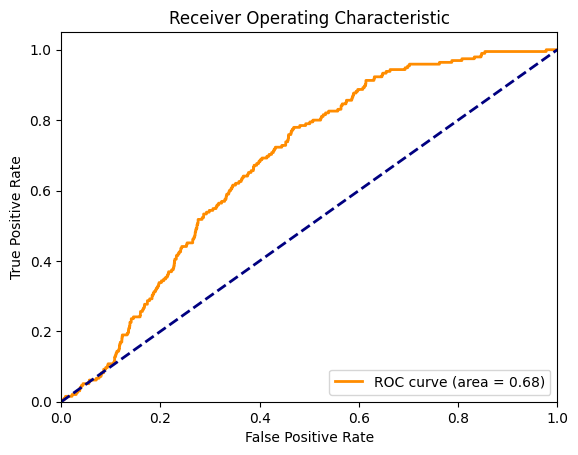

In [27]:
# prompt: find roc curve for this

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming you have predictions and true labels
# Replace these with your actual predictions and true labels
y_pred_probs = []  # Probabilities for the positive class (lens)
y_true = []

# Iterate through the test data loader and get predictions
with torch.no_grad():
    for X, y in test_loader:
        X = X.to("cpu")
        y = y.to("cpu")
        test_logits = model_0(X)
        test_pred_probs = torch.softmax(test_logits, dim=1)
        y_pred_probs.extend(test_pred_probs[:, 1].tolist()) # Probability of being a lens
        y_true.extend(y.tolist())

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.show()


In [28]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format).
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [31]:
# prompt: creating training loop and training a model on batches of data

# Set the number of epochs
epochs = 5 #@param {type:"integer"}

# Put data to target device
train_features_batch = train_features_batch.to("cpu")
train_labels_batch = train_labels_batch.to("cpu")

# Convert test_data and test_labels to Tensors and move to device for inference
test_data = torch.from_numpy(test_data).float().to("cpu")
test_labels = torch.from_numpy(test_labels).long().to("cpu")

# Training loop
for epoch in range(epochs):
    print(f"Epoch: {epoch}\n---------")
    train_loss = 0

    # Add a timer to track how long each epoch takes
    start_time = timer()

    # Loop through training batches
    for batch, (X, y) in enumerate(train_loader):
        model_0.train() # put model in training mode
        # 1. Forward pass
        y_pred = model_0(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Print out what's happening every 100 batches
        if batch % 100 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_loader.dataset)} samples")

    # Divide total train loss by length of train dataloader
    train_loss /= len(train_loader)

    # Get end timer
    end_time = timer()

    # Print out training time
    print_train_time(start=start_time, end=end_time, device="cpu")

    # Put model in evaluation mode and check accuracy on test set
    model_0.eval()
    with torch.inference_mode():
      test_pred = model_0(test_data)
      test_acc = accuracy_fn(y_true=test_labels,
                            y_pred=test_pred.argmax(dim=1))
      print(f"Test Accuracy: {test_acc:.2f}%")

Epoch: 0
---------
Looked at 0/40785 samples
Looked at 3200/40785 samples
Looked at 6400/40785 samples
Looked at 9600/40785 samples
Looked at 12800/40785 samples
Looked at 16000/40785 samples
Looked at 19200/40785 samples
Looked at 22400/40785 samples
Looked at 25600/40785 samples
Looked at 28800/40785 samples
Looked at 32000/40785 samples
Looked at 35200/40785 samples
Looked at 38400/40785 samples
Train time on cpu: 7.710 seconds
Test Accuracy: 93.22%
Epoch: 1
---------
Looked at 0/40785 samples
Looked at 3200/40785 samples
Looked at 6400/40785 samples
Looked at 9600/40785 samples
Looked at 12800/40785 samples
Looked at 16000/40785 samples
Looked at 19200/40785 samples
Looked at 22400/40785 samples
Looked at 25600/40785 samples
Looked at 28800/40785 samples
Looked at 32000/40785 samples
Looked at 35200/40785 samples
Looked at 38400/40785 samples
Train time on cpu: 6.142 seconds
Test Accuracy: 89.64%
Epoch: 2
---------
Looked at 0/40785 samples
Looked at 3200/40785 samples
Looked at 64

#PRACTIZES


In [35]:
# Create a random tensor of size (3, 4)
random_tensor = torch.rand(size=(3, 3, 1, 2))
random_tensor, random_tensor.dtype

(tensor([[[[0.9911, 0.9442]],
 
          [[0.1755, 0.0541]],
 
          [[0.9175, 0.3486]]],
 
 
         [[[0.1505, 0.1508]],
 
          [[0.6920, 0.8553]],
 
          [[0.2776, 0.6784]]],
 
 
         [[[0.7946, 0.1094]],
 
          [[0.7253, 0.4242]],
 
          [[0.0733, 0.2079]]]]),
 torch.float32)

In [34]:
# Create a tensor
x = torch.arange(1., 9.)
x, x.shape

# Add an extra dimension
x_reshaped = x.reshape(2, 4)
x_reshaped, x_reshaped.shape

print(f"Previous tensor hehe: {x}")
print(f"Previous shape hehe: {x.shape}")

# Remove extra dimension from x_reshaped
x_squeezed = x_reshaped.squeeze()
print(f"\nNew tensor: {x_squeezed}")
print(f"New shape: {x_squeezed.shape}")

print(f"Previous tensor: {x_squeezed}")
print(f"Previous shape: {x_squeezed.shape}")

## Add an extra dimension with unsqueeze
x_unsqueezed = x_squeezed.unsqueeze(dim=0)
print(f"\nNew tensor: {x_unsqueezed}")
print(f"New shape: {x_unsqueezed.shape}")

Previous tensor hehe: tensor([1., 2., 3., 4., 5., 6., 7., 8.])
Previous shape hehe: torch.Size([8])

New tensor: tensor([[1., 2., 3., 4.],
        [5., 6., 7., 8.]])
New shape: torch.Size([2, 4])
Previous tensor: tensor([[1., 2., 3., 4.],
        [5., 6., 7., 8.]])
Previous shape: torch.Size([2, 4])

New tensor: tensor([[[1., 2., 3., 4.],
         [5., 6., 7., 8.]]])
New shape: torch.Size([1, 2, 4])


##Observing characters of Lens vs Non Lens

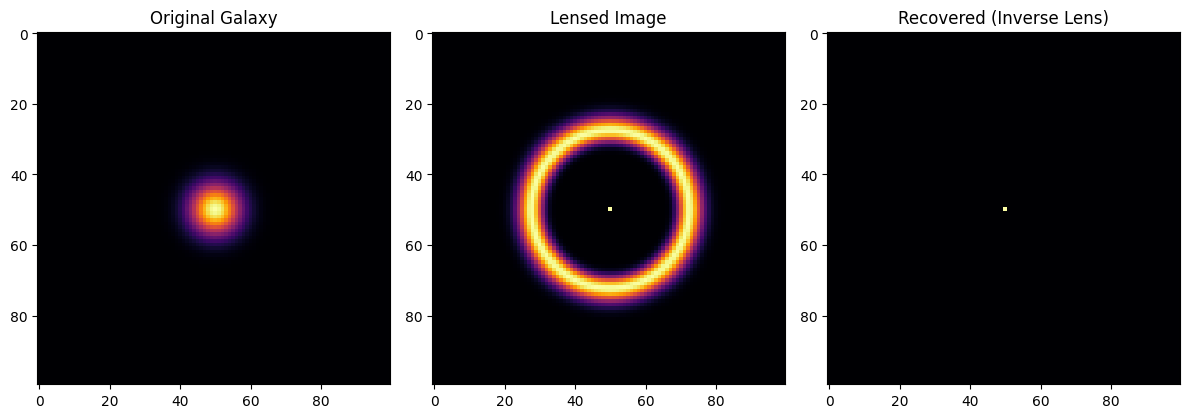

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates

# Step 1: Create a fake galaxy (a bright spot)
def make_galaxy_image(size=100, center=(50, 50), radius=5):
    y, x = np.meshgrid(np.arange(size), np.arange(size))
    dist = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    galaxy = np.exp(-(dist**2) / (2 * radius**2))
    return galaxy

# Step 2: Add lensing effect (simulate deflection by mass)
def lens_image(image, lens_center=(50, 50), strength=500):
    y, x = np.meshgrid(np.arange(image.shape[0]), np.arange(image.shape[1]))

    dx = x - lens_center[0]
    dy = y - lens_center[1]
    r_squared = dx**2 + dy**2 + 1e-6  # avoid division by zero

    # Gravitational deflection (simplified Einstein radius deflection)
    alpha_x = strength * dx / r_squared
    alpha_y = strength * dy / r_squared

    # Apply deflection to pixel positions
    x_lensed = x - alpha_x
    y_lensed = y - alpha_y

    # Map lensed coordinates back to original image
    lensed = map_coordinates(image, [y_lensed.ravel(), x_lensed.ravel()], order=1, mode='constant')
    return lensed.reshape(image.shape), (x_lensed, y_lensed)

# Step 3: Try the inverse lens equation to undo the distortion
def inverse_lens_image(lensed_image, lens_center=(50, 50), strength=500):
    y, x = np.meshgrid(np.arange(lensed_image.shape[0]), np.arange(lensed_image.shape[1]))

    dx = x - lens_center[0]
    dy = y - lens_center[1]
    r_squared = dx**2 + dy**2 + 1e-6

    alpha_x = strength * dx / r_squared
    alpha_y = strength * dy / r_squared

    # Inverse lensing (backward warping)
    x_source = x + alpha_x
    y_source = y + alpha_y

    # Map back to source plane
    source_recovered = map_coordinates(lensed_image, [y_source.ravel(), x_source.ravel()], order=1, mode='constant')
    return source_recovered.reshape(lensed_image.shape)

# Run simulation
original = make_galaxy_image()
lensed, coords = lens_image(original)
recovered = inverse_lens_image(lensed)

# Plot results
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Original Galaxy")
plt.imshow(original, cmap='inferno')

plt.subplot(1, 3, 2)
plt.title("Lensed Image")
plt.imshow(lensed, cmap='inferno')

plt.subplot(1, 3, 3)
plt.title("Recovered (Inverse Lens)")
plt.imshow(recovered, cmap='inferno')

plt.tight_layout()
plt.show()
